In [48]:
from pathlib import Path
import hashlib, csv, re, sys
import numpy as np
import h5py
import spe_loader as sl
import json
from typing import Any
from lightfield_processing import *
import matplotlib.pyplot as plt
import scipy.integrate

In [49]:
RAW_DIR   = Path("G:\\Shared drives\\Shumlak Lab\\Diagnostics\\Spectroscopy\\S_XB\\Data\\Ops")
OUT_H5    = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\experiment.h5")
MANIFEST  = Path("G:\\Shared drives\\Shumlak Lab\\Users\\Current\\Elyse Lian\\Python Code\\Spectroscopy\\manifest.csv")

In [55]:
shot=250424010
attrs = get_shot_attributes(OUT_H5, shot_id=shot)
img_data  = attrs["image"]
print(img_data.shape) 
print(attrs["dataset_attrs"]["Acceleration Voltage (kV)"])

plt.imshow(img_data, cmap='gray')
plt.colorbar()

(1024, 1024)
4455.583518743515


In [56]:
import h5py

with h5py.File(OUT_H5, "r") as f:
    print("Top-level keys:", list(f.keys()))
    if "shots" in f:
        keys = list(f["shots"].keys())
        print("Number of shots:", len(keys))
        print("First 20 shot keys:", keys[:20])
        print("Contains 250219017?", "250219017" in keys)
        # Also check legacy style
        print("Contains 250219_017?", "250219_017" in keys)
        print("Contains 250219_17?", "250219_17" in keys)

Top-level keys: ['meta', 'shots']
Number of shots: 384
First 20 shot keys: ['250219017', '250219018', '250219019', '250219020', '250219021', '250219022', '250219023', '250219024', '250219025', '250219026', '250416002', '250416003', '250416004', '250416005', '250416006', '250416007', '250423001', '250423002', '250423003', '250423004']
Contains 250219017? True
Contains 250219_017? False
Contains 250219_17? False


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Testing file: G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe
Shape: (1024, 1024)
Dtype: float32


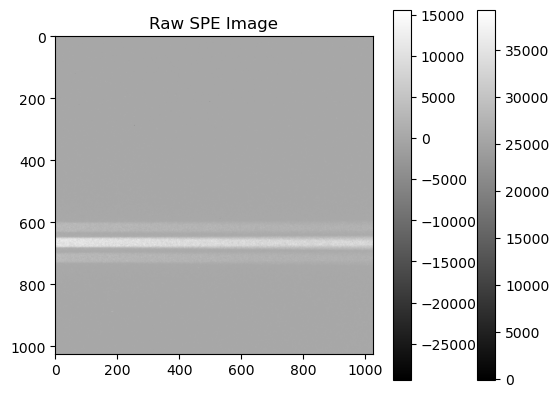

In [57]:
%load_ext autoreload
%autoreload 2

from regions_processing import *

# test_file = os.path.join(CAL_FOLDER, f"{CAL_PREFIX}  007.spe")
test_file = r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422\250422  020.spe"

print("Testing file:", test_file)

img = load_spe_image(test_file)

print("Shape:", img.shape)
print("Dtype:", img.dtype)
# print("Min / Max:", img.min(), img.max())
# attrs = get_shot_attributes(OUT_H5, shot_id=250422015)
# gate_shot = attrs["dataset_attrs"]["Gate Width (ns)"]

plt.imshow(img, cmap='gray')
plt.title("Raw SPE Image")
plt.colorbar()
plt.show()

Found 29 SPE files
Using 23 SPE files (skipping first 6)


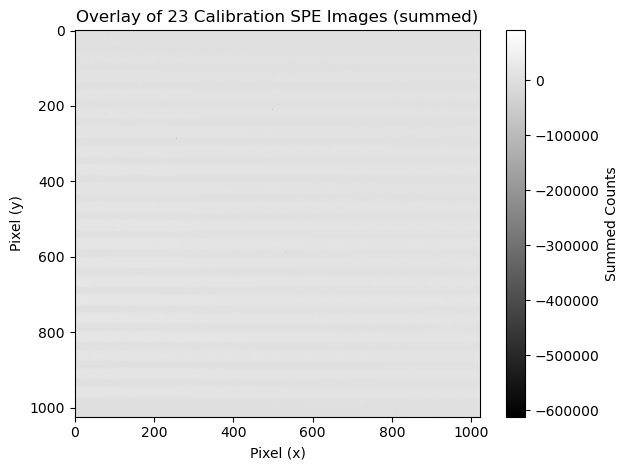

In [58]:
from pathlib import Path

cal_folder = Path(r"G:\Shared drives\Shumlak Lab\Diagnostics\Spectroscopy\S_XB\Data\Calibration\250422")
spe_files = sorted(cal_folder.glob("*.spe"))

print(f"Found {len(spe_files)} SPE files")
if len(spe_files) <= 6:
    print("Warning: <= 6 SPE files found; skipping first 6 leaves none to stack.")

spe_files_used = spe_files[6:]
print(f"Using {len(spe_files_used)} SPE files (skipping first 6)")

# Load all images and sum them into one overlay
stacked = None
for f in spe_files_used:
    img = load_spe_image(str(f))
    if stacked is None:
        stacked = img.astype(np.float64)
    else:
        stacked += img.astype(np.float64)

plt.figure()
plt.imshow(stacked, cmap='gray', aspect='auto')
plt.title(f"Overlay of {len(spe_files_used)} Calibration SPE Images (summed)")
plt.xlabel("Pixel (x)")
plt.ylabel("Pixel (y)")
plt.colorbar(label="Summed Counts")
plt.tight_layout()
plt.show()

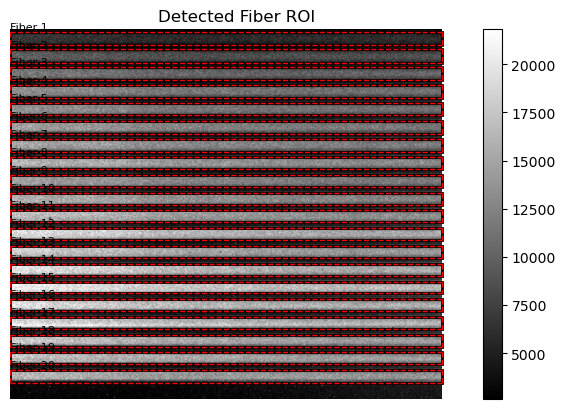

In [59]:
fibers = extract_fiber_and_calibrate(
    stacked,
    lamp_csv_path=LAMP_CSV_PATH,
    sauvola_k=0.01,
    smooth_window=5)

if fibers is None:
    print("No region found.")
else:
    # for fiber in fibers:
    #     print("BBox:", fiber["bbox"])
    #     print("Centroid:", fiber["centroid_index"])
    #     print("Area:", fiber["area"])
    show_fiber_boxes(stacked, fibers, title="Detected Fiber ROI")

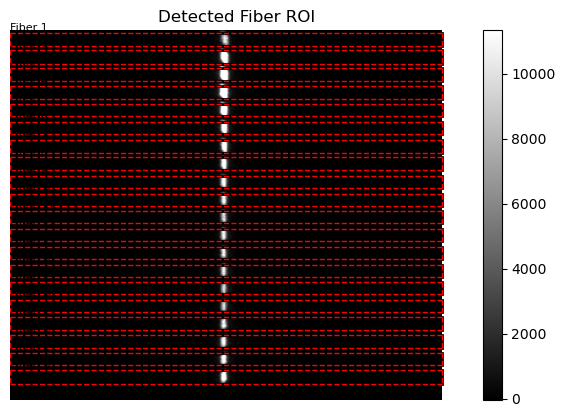

In [60]:
show_fiber_boxes(img_data, fibers, title="Detected Fiber ROI")



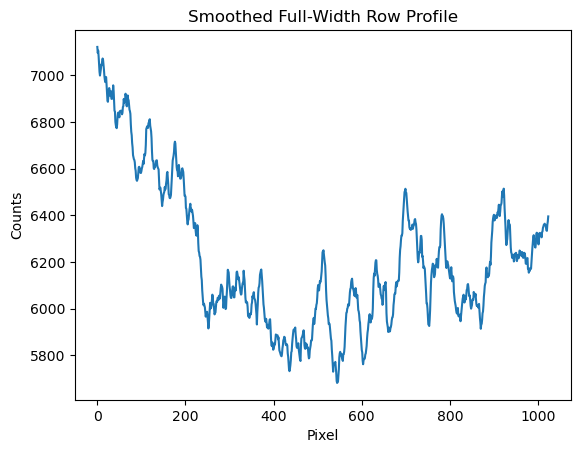

In [61]:
row_profile = fibers[0]["row_profile_full"]

plt.plot(row_profile)
plt.title("Smoothed Full-Width Row Profile")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.show()

Multiplier shape: (1024,)


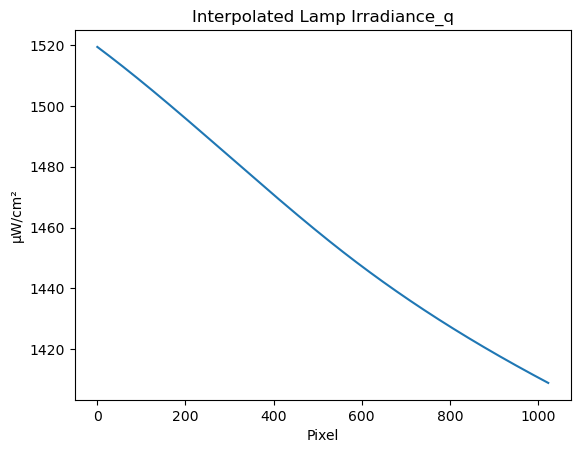

In [62]:
irr_test = get_irradiance_multiplier(
    row_profile,
    lamp_csv_path=LAMP_CSV_PATH)

print("Multiplier shape:", irr_test["multiplier_uW_cm2_per_count"].shape)

plt.plot(irr_test["irradiance_q_uW_cm2"])
plt.title("Interpolated Lamp Irradiance_q")
plt.xlabel("Pixel")
plt.ylabel("µW/cm²")
plt.show()

In [63]:
shot=250424015
attrs = get_shot_attributes(OUT_H5, shot_id=shot)
img_data  = attrs["image"]
# print(img_data.shape) 
# print(attrs["dataset_attrs"]["Acceleration Voltage (kV)"])

# plt.imshow(img_data, cmap='gray')
# plt.colorbar()

real_result = extract_real_image_fiber_intensities(
    img=img_data,
    fibers=fibers,   # from your calibration-image extraction
    min_area=20,
    sauvola_window=31,
    sauvola_k=0.2,
    profile_half_height=3
)

fiber_intensities = real_result["fiber_intensities_uW_cm2"]
print(fiber_intensities)

plt.plot(fiber_intensities, marker='.')
plt.ylabel("Fiber Intensity (µW/cm²)")
plt.xlabel("Fiber Index")
plt.title("Calibrated Fiber Intensities")

c:\Users\elyse\Downloads\Python\Zap\spectroscopy\regions_processing.py:71: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  


[2666.12494937 2376.39230307 1994.28495195 1562.35201212 1069.59808491
  825.46253165  661.30216162  576.26042961  622.04952249  610.0497379
  597.65194511  574.1250896   530.25705619  527.84024806  486.92237642
  505.28204462  738.92561996  954.61994265 1132.48982258 1293.21050713]


Text(0.5, 1.0, 'Calibrated Fiber Intensities')

Gate width: 50.0 ns (5.000e-08 s)
160524021 linear density is 7069575688749126656: 
Converged in 454 iterations: gamma = 0.005460, Linear density = 7153614468239797248


c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:247: RuntimeWarning: divide by zero encountered in divide
  linestyle='none',
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:247: RuntimeWarning: invalid value encountered in multiply
  linestyle='none',
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:246: RuntimeWarning: divide by zero encountered in scalar divide
  capsize=5,
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:253: RuntimeWarning: invalid value encountered in multiply
  plt.ylabel('$n_e$ [10$^{23}$ m$^{-3}$]')


Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Using DHI/MDSplus-based SXB (per chord) with fallback: profile used for 4/20 chords
SXB const fallback = 68.1 ionizations/photon
SXB chords range  = [10.73, 68.1] ionizations/photon
[5.37446159e+30 4.70652150e+30 6.67816572e+29 4.83760412e+29
 2.09990479e+30 2.02360373e+30 2.19365457e+30 2.20369860e+30
 2.38601003e+30 2.48378544e+30]

Abel inversion (analysis_notebook params; 5 center-most chords) shell emissivities:
  chords used: 5
  shell[00] = 1.50455e+29
  shell[01] = 1.00672e+29
  shell[02] = 6.27621e+28
  shell[03] = 8.74385e+28
  shell[04] = 2.27404e+29
  inner_shell_emissivity = 2.274039248176628e+29
  cond(L) = 3709.138634929967

Per-fiber results (first 5):
i= 0  x=-11.80 mm  Gamma=1.108e+31 atoms/m^2/s  m_dot=1.110e+05 mg/s
i= 1  x=-10.56 mm  Gamma=9.876e+30 atoms/m^2/s  m_dot=9.892e+04 mg/s
i= 2  x= -9.32 mm

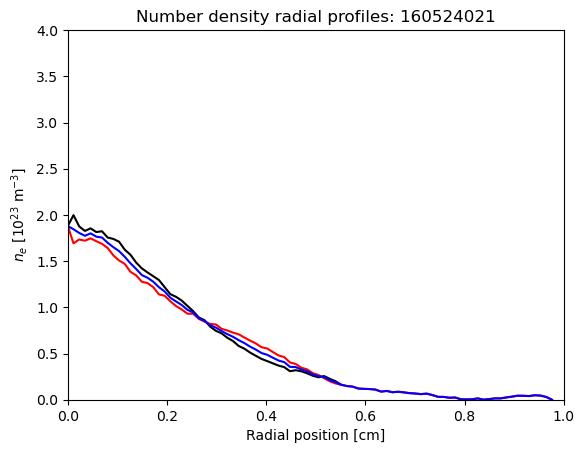

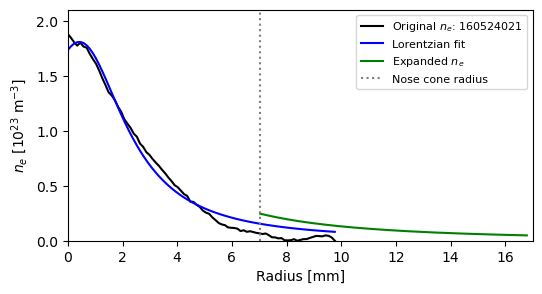

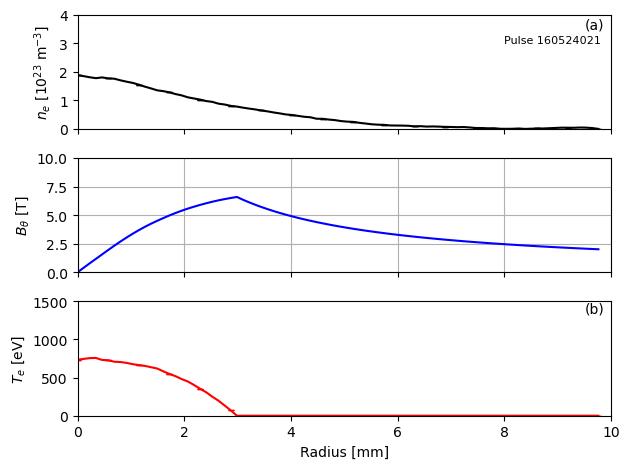

<Figure size 640x480 with 0 Axes>

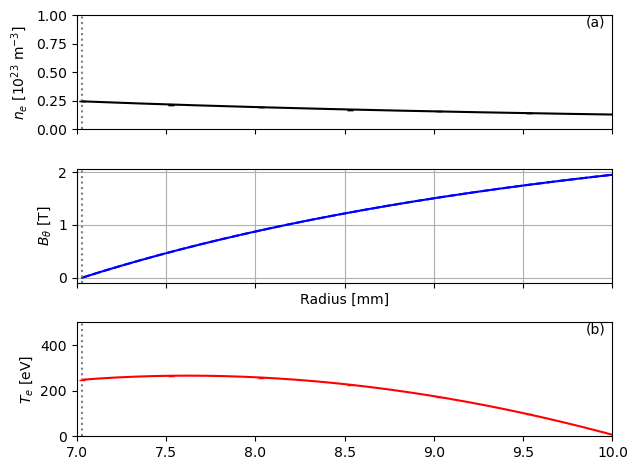

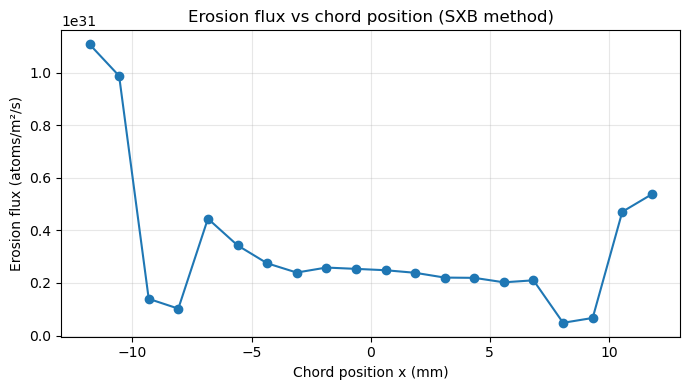

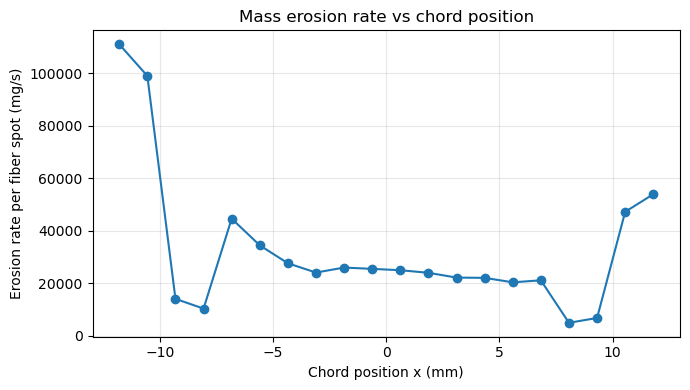

(1024, 1024)
4455.583518743515


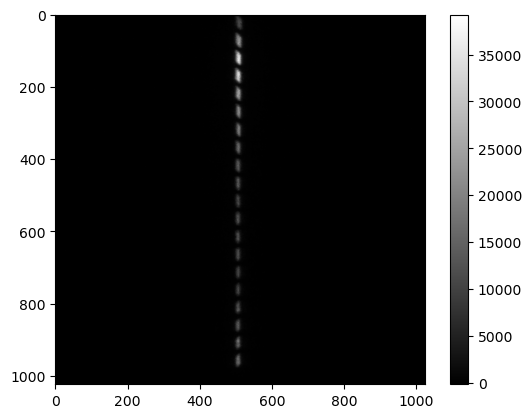

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from read_sxb_class import read_sxb

if "fiber_intensities" not in globals():
    raise NameError("Expected `fiber_intensities` from Cell 11 (fiber_intensities_uW_cm2).")

# Gate width from HDF5 attrs (ns -> s)
gate_ns = None
if "attrs" in globals():
    gate_ns = attrs.get("dataset_attrs", {}).get("Gate Width (ns)", None)
if gate_ns is None:
    gate_ns = attrs.get("dataset_attrs", {}).get("Gate Width", None) if "attrs" in globals() else None
if gate_ns is None:
    raise KeyError("Could not find Gate Width (ns) in `attrs['dataset_attrs']`. Re-run Cell 3 or provide gate_ns manually.")
gate_exp_s = float(gate_ns) * 1e-9
print(f"Gate width: {gate_ns} ns ({gate_exp_s:.3e} s)")

# Calibration exposure time used implicitly by the lamp-derived multiplier.
# This matches the PI-MAX4 max exposure used in `SXB_Analysis.py`.
gate_cal_s = 21.0

# Wavelength for C-III line used throughout the SXB pipeline
lambda_nm = 229.7
h = 6.62607015e-34
c = 299_792_458.0
E_ph = h * c / (lambda_nm * 1e-9)  # J/photon

# Carbon atom mass (mg) (matches `sxb_campaign.py`)
m_C_mg = 1.9926e-20

# Spot size on the nose cone (radius in meters) (matches `sxb_campaign.py` comment)
r_spot_m = 400e-6
A_spot_m2 = np.pi * r_spot_m**2

# ----------------------------
# Fiber index -> chord position mapping
# ----------------------------
fiber_idx = np.arange(len(fiber_intensities))
x_mm = np.linspace(-23.6 / 2, 23.6 / 2, len(fiber_intensities))  # signed chord position
r_mm = x_mm
r_m = 1e-3 * r_mm

# ----------------------------
# Irradiance -> photon flux
# ----------------------------
I_uW_cm2 = np.asarray(fiber_intensities, dtype=float)
I_W_m2_raw = I_uW_cm2 * 1e-6 * 1e4  # (µW/cm^2) -> (W/m^2)

# Correct for the calibration/shot exposure mismatch (counts scale ~ linearly with exposure).
# Without this, the multiplier effectively returns ~irradiance * (gate_exp/gate_cal).
gate_corr = gate_cal_s / gate_exp_s
I_W_m2 = I_W_m2_raw * gate_corr

photon_flux = I_W_m2 / E_ph  # photons / m^2 / s

# ----------------------------
# SXB coefficient -> erosion flux
# ----------------------------
# Default (constant) parameters used in SXB_Analysis.py
Te_eV = 500.0
ne_m3 = 1e23

# Optional: use DHI/MDSplus profiles (same path as SXB_Analysis.py via `dhi_profiles`)
USE_DHI_PROFILE_SXB = True
DHI_RADIUS_M = 0.003  # meters; matches `read_dhi_mds.py` __main__ example

# Create an instance of the SXB coefficient reader
sxb_vals = read_sxb("C-III")

# Constant SXB (fallback)
sxb_const = float(sxb_vals.get_sxb(Te_eV, ne_m3))

sxb_chords = None
if USE_DHI_PROFILE_SXB:
    try:
        from read_dhi_mds import dhi_profiles

        # Returns: r (m), ne(r), Btheta(r), Te(r), and error arrays
        r_dhi, ne_dhi, _, te_dhi, *_ = dhi_profiles("lateral", radius=float(DHI_RADIUS_M))

        r_dhi = np.asarray(r_dhi, dtype=float)
        ne_dhi = np.asarray(ne_dhi, dtype=float)
        te_dhi = np.asarray(te_dhi, dtype=float)

        # Ensure monotonic increasing radius for interpolation
        order = np.argsort(r_dhi)
        r_dhi = r_dhi[order]
        ne_dhi = ne_dhi[order]
        te_dhi = te_dhi[order]

        # Chord positions (impact parameters) in meters
        chord_pos_m = np.abs(1e-3 * np.linspace(-23.6 / 2, 23.6 / 2, 20))

        # Interpolate ne and Te onto chord locations; out-of-range -> NaN
        ne_ch = np.interp(chord_pos_m, r_dhi, ne_dhi, left=np.nan, right=np.nan)
        te_ch = np.interp(chord_pos_m, r_dhi, te_dhi, left=np.nan, right=np.nan)

        # Compute chord-dependent SXB; fallback to constant when profile values are invalid
        sxb_chords = np.empty_like(chord_pos_m, dtype=float)
        used_profile = 0
        for i in range(chord_pos_m.size):
            te_i = float(te_ch[i])
            ne_i = float(ne_ch[i])
            if np.isfinite(te_i) and np.isfinite(ne_i) and te_i > 0 and ne_i > 0:
                sxb_chords[i] = float(sxb_vals.get_sxb(te_i, ne_i))
                used_profile += 1
            else:
                sxb_chords[i] = sxb_const

        print(
            f"Using DHI/MDSplus-based SXB (per chord) with fallback: "
            f"profile used for {used_profile}/20 chords"
        )
        print(f"SXB const fallback = {sxb_const:.4g} ionizations/photon")
        print(
            f"SXB chords range  = [{np.nanmin(sxb_chords):.4g}, {np.nanmax(sxb_chords):.4g}] ionizations/photon"
        )

    except Exception as e:
        print("DHI/MDSplus SXB failed; falling back to constant SXB. Error:", repr(e))
        sxb_chords = None

if sxb_chords is None:
    print(f"Using constant SXB(C-III) at Te={Te_eV:g} eV, ne={ne_m3:.3g} m^-3: {sxb_const:.4g} ionizations/photon")
    sxb_chords = np.full(20, sxb_const, dtype=float)

# Erosion flux: atoms / m^2 / s (vector, per chord)
erosion_flux_atoms_m2_s = 4.0 * np.pi * sxb_chords * photon_flux

DO_ABEL_INVERSION = True

# Abel inversion regularization parameters
ABEL_LAM = 1.0
ABEL_W_INNER = 1.0
ABEL_R_MM = 11.8
ABEL_ELEC_RAD_MM = 0.4
ABEL_N_SHELLS = 5

# Only use the 5 chords closest to the center *after* applying the same preprocessing
# as analysis_notebook (ascending_suffix + electrode crop)
ABEL_USE_N_CHORDS = 5

abel_eps = None
abel_diag = None
if DO_ABEL_INVERSION:
    from shot_processing import ascending_suffix, build_L_onion, tikhonov_inversion

    chord_vec = np.asarray(erosion_flux_atoms_m2_s, dtype=float)
    if chord_vec.size != 20:
        raise ValueError(f"Expected 20 chords, got {chord_vec.size}.")

    # Same half and ordering as analysis_notebook.ipynb
    b_raw = np.linspace(11.8, 0.0, 10)
    I_left = chord_vec[:10]  # center -> inner
    I_right = np.flip(chord_vec[10:])  # outer -> center
    print(I_right)
    # I_use = I_left
    I_use = I_right

    # Same preprocessing as analysis_notebook / prepare_and_peel
    b_keep, I_keep = ascending_suffix(b_raw, I_use, elec_rad=float(ABEL_ELEC_RAD_MM), inner_chord_num=0)

    if len(b_keep) < int(ABEL_USE_N_CHORDS):
        print(
            f"\nAbel inversion skipped: only {len(b_keep)} usable chord(s) after ascending_suffix/electrode crop "
            f"(need {ABEL_USE_N_CHORDS})."
        )
    else:
        # Use ONLY the N chords closest to center (smallest b), in outer->center order
        b_used = np.asarray(b_keep, float)[-int(ABEL_USE_N_CHORDS):]
        I_used = np.asarray(I_keep, float)[-int(ABEL_USE_N_CHORDS):]

        # 5 shells, matching analysis_notebook parameters
        edges = np.linspace(float(ABEL_R_MM), float(ABEL_ELEC_RAD_MM) - 0.4, int(ABEL_N_SHELLS) + 1)
        L = build_L_onion(b_used, edges, elec_rad=float(ABEL_ELEC_RAD_MM))

        try:
            eps_rec = tikhonov_inversion(L, I_used, lam=float(ABEL_LAM), w_inner=float(ABEL_W_INNER))
            abel_eps = np.asarray(eps_rec, dtype=float)
            abel_diag = {
                "b_used": np.asarray(b_used, dtype=float),
                "I_used": np.asarray(I_used, dtype=float),
                "L": np.asarray(L, dtype=float),
                "edges": np.asarray(edges, dtype=float),
            }

            print("\nAbel inversion (analysis_notebook params; 5 center-most chords) shell emissivities:")
            print(f"  chords used: {len(abel_diag['b_used'])}")
            for i, v in enumerate(abel_eps):
                print(f"  shell[{i:02d}] = {v:.6g}")
            print("  inner_shell_emissivity =", float(abel_eps[-1]))
            print("  cond(L) =", float(np.linalg.cond(abel_diag["L"])))

        except Exception as e:
            print("Abel inversion failed:", repr(e))

# ----------------------------
# Mass erosion rate per fiber spot
# ----------------------------
erosion_rate_mg_s = erosion_flux_atoms_m2_s * m_C_mg * A_spot_m2
mass_flux_mg_m2_s = erosion_flux_atoms_m2_s * m_C_mg

# ----------------------------
# Quick sanity outputs
# ----------------------------
print("\nPer-fiber results (first 5):")
for i in range(min(5, len(fiber_idx))):
    print(
        f"i={i:2d}  x={x_mm[i]:6.2f} mm  "
        f"Gamma={erosion_flux_atoms_m2_s[i]:.3e} atoms/m^2/s  "
        f"m_dot={erosion_rate_mg_s[i]:.3e} mg/s"
    )

print("\nTotals over all 20 fiber spots (sum of mg/s over spots):")
print("  sum(m_dot) =", float(np.nansum(erosion_rate_mg_s)), "mg/s")

# ----------------------------
# Plots
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(r_mm, erosion_flux_atoms_m2_s, "o-")
plt.xlabel("Chord position x (mm)")
plt.ylabel("Erosion flux (atoms/m²/s)")
plt.title("Erosion flux vs chord position (SXB method)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(r_mm, erosion_rate_mg_s, "o-")
plt.xlabel("Chord position x (mm)")
plt.ylabel("Erosion rate per fiber spot (mg/s)")
plt.title("Mass erosion rate vs chord position")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

shot=250424010
attrs = get_shot_attributes(OUT_H5, shot_id=shot)
img_data  = attrs["image"]
print(img_data.shape) 
print(attrs["dataset_attrs"]["Acceleration Voltage (kV)"])

plt.imshow(img_data, cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from lightfield_processing import get_shot_attributes
from regions_processing import extract_real_image_fiber_intensities
from shot_processing import ascending_suffix, build_L_onion, tikhonov_inversion
from read_sxb_class import read_sxb

# ----------------------------
# Config
# ----------------------------
date_prefixes = ["250219", "250416", "250423", "250424", "250428", "250514", "250609"]

# Drop shots if ANY Abel shell emissivity is zero (or negative)
EPS_ZERO_TOL = 0.0  # set to e.g. 1e-30 if you want a tolerance

# Abel settings
ABEL_LAM = 1.0
ABEL_W_INNER = 1.0
ABEL_R_MM = 11.8
ABEL_ELEC_RAD_MM = 0.4
ABEL_N_SHELLS = 5
ABEL_USE_N_CHORDS = 5

# Photon conversion settings
lambda_nm = 229.7
h = 6.62607015e-34
c = 299_792_458.0
E_ph = h * c / (lambda_nm * 1e-9)

# Exposure correction toggle (matches your earlier Cell 12 logic)
APPLY_GATE_CORR = True
gate_cal_s = 21.0

def _get_gate_ns(attrs_dict):
    d = attrs_dict.get("dataset_attrs", {}) if isinstance(attrs_dict, dict) else {}
    return d.get("Gate Width (ns)", d.get("Gate Width", None))

# ----------------------------
# SXB scalar (computed ONCE) from DHI default shot at r ≈ 7 mm
# ----------------------------
sxb_vals = read_sxb("C-III")

DHI_RADIUS_M = 0.007  # 7 mm (meters)
try:
    from read_dhi_mds import dhi_profiles
    # IMPORTANT: per your request, do NOT pass a shot argument here; use dhi_profiles default shot.
    r_dhi, ne_dhi, _, te_dhi, *_ = dhi_profiles("lateral", radius=float(DHI_RADIUS_M))
    plt.close('all')
except Exception as e:
    plt.close('all')
    raise RuntimeError(
        "Failed to load DHI/MDSplus profiles for default shot. "
        "Cannot compute SXB scalar at 7 mm. Error: " + repr(e)
    )

r_dhi = np.asarray(r_dhi, dtype=float)
ne_dhi = np.asarray(ne_dhi, dtype=float)
te_dhi = np.asarray(te_dhi, dtype=float)

# Use |r| and sort so interpolation is well-defined
r_dhi = np.abs(r_dhi)
order = np.argsort(r_dhi)
r_dhi = r_dhi[order]
ne_dhi = ne_dhi[order]
te_dhi = te_dhi[order]

good = np.isfinite(r_dhi) & np.isfinite(ne_dhi) & np.isfinite(te_dhi)
r_dhi = r_dhi[good]
ne_dhi = ne_dhi[good]
te_dhi = te_dhi[good]

if r_dhi.size < 2:
    raise RuntimeError("DHI profile has too few finite points to interpolate")

# Interpolate Te/ne at 7 mm; if 7 mm is outside returned range, clip to nearest edge
r_min = float(np.nanmin(r_dhi))
r_max = float(np.nanmax(r_dhi))
r_query = float(DHI_RADIUS_M)
r_used = min(max(r_query, r_min), r_max)
if r_used != r_query:
    print(
        f"Note: DHI profile radius range is [{1e3*r_min:.3f}, {1e3*r_max:.3f}] mm; "
        f"using nearest available radius {1e3*r_used:.3f} mm instead of 7.000 mm."
    )

ne_used = float(np.interp(r_used, r_dhi, ne_dhi))
te_used = float(np.interp(r_used, r_dhi, te_dhi))
if (not np.isfinite(ne_used)) or (not np.isfinite(te_used)) or (ne_used <= 0) or (te_used <= 0):
    raise RuntimeError(f"Invalid DHI Te/ne at r_used={r_used} m: Te={te_used}, ne={ne_used}")

sxb_scalar = float(sxb_vals.get_sxb(te_used, ne_used))
if (not np.isfinite(sxb_scalar)) or (sxb_scalar <= 0):
    raise RuntimeError(f"Invalid SXB computed at r_used={r_used} m: {sxb_scalar}")

print(f"Using SXB scalar from DHI default shot at r={1e3*r_used:.3f} mm: Te={te_used:.6g} eV, ne={ne_used:.6g} m^-3, SXB={sxb_scalar:.6g} ionizations/photon")

def abel_shell_emissivities_for_shot(shot_id: int):
    """
    Returns Abel-recovered shell emissivities, scaled by SXB *after* inversion.

    - Performs Abel inversion on a base signal with SXB factored out.
    - Then multiplies recovered emissivities by the single scalar SXB value (sxb_scalar).
    """
    attrs = get_shot_attributes(OUT_H5, shot_id=int(shot_id))
    img = attrs["image"]

    real_result = extract_real_image_fiber_intensities(
        img=img,
        fibers=fibers,
        min_area=20,
        sauvola_window=31,
        sauvola_k=0.2,
        profile_half_height=3,
    )
    fiber_intensities_uW_cm2 = np.asarray(real_result["fiber_intensities_uW_cm2"], dtype=float)
    if fiber_intensities_uW_cm2.size != 20:
        raise ValueError(f"Expected 20 fibers, got {fiber_intensities_uW_cm2.size}")

    # Irradiance -> photon flux
    I_W_m2_raw = fiber_intensities_uW_cm2 * 1e-6 * 1e4  # (µW/cm^2) -> (W/m^2)
    if APPLY_GATE_CORR:
        gate_ns = _get_gate_ns(attrs)
        if gate_ns is None:
            raise KeyError("Missing Gate Width (ns) / Gate Width in dataset_attrs")
        gate_exp_s = float(gate_ns) * 1e-9
        gate_corr = gate_cal_s / gate_exp_s
        I_W_m2 = I_W_m2_raw * gate_corr
    else:
        I_W_m2 = I_W_m2_raw

    photon_flux = I_W_m2 / E_ph  # photons / m^2 / s

    # Base chord signal with SXB factored out
    # Original: erosion_flux = (4*pi) * SXB * photon_flux
    # Here: invert base = (4*pi) * photon_flux, then apply SXB scalar AFTER inversion.
    chord_vec_base = 4.0 * np.pi * np.asarray(photon_flux, dtype=float)
    if chord_vec_base.size != 20:
        raise ValueError(f"Expected 20 chords, got {chord_vec_base.size}.")

    # Abel inversion (same chord selection and preprocessing)
    b_raw = np.linspace(11.8, 0.0, 10)
    I_right = np.flip(chord_vec_base[10:])  # outer -> center
    I_use = I_right

    b_keep, I_keep = ascending_suffix(
        b_raw, I_use,
        elec_rad=float(ABEL_ELEC_RAD_MM),
        inner_chord_num=0,
    )

    if len(b_keep) < int(ABEL_USE_N_CHORDS):
        return np.full(int(ABEL_N_SHELLS), np.nan, dtype=float)

    b_used = np.asarray(b_keep, float)[-int(ABEL_USE_N_CHORDS):]
    I_used = np.asarray(I_keep, float)[-int(ABEL_USE_N_CHORDS):]

    edges = np.linspace(float(ABEL_R_MM), float(ABEL_ELEC_RAD_MM) - 0.4, int(ABEL_N_SHELLS) + 1)
    L = build_L_onion(b_used, edges, elec_rad=float(ABEL_ELEC_RAD_MM))

    eps_base = tikhonov_inversion(L, I_used, lam=float(ABEL_LAM), w_inner=float(ABEL_W_INNER))
    eps_base = np.asarray(eps_base, dtype=float)
    if eps_base.size != int(ABEL_N_SHELLS):
        raise ValueError(f"Expected {ABEL_N_SHELLS} shells, got {eps_base.size}")

    # Apply SXB scalar AFTER inversion
    eps_scaled = eps_base * float(sxb_scalar)
    return eps_scaled

# ----------------------------
# Find matching shots in H5
# ----------------------------
with h5py.File(OUT_H5, "r") as f:
    shot_keys = list(f["shots"].keys())

selected_keys = [k for k in shot_keys if any(str(k).startswith(p) for p in date_prefixes)]
selected_keys = sorted(selected_keys, key=lambda s: int(str(s)))
print(f"Found {len(selected_keys)} shots matching prefixes.")

# ----------------------------
# Run batch; drop zeros; keep shot-ordered arrays
# ----------------------------
kept_shots = []
kept_prefixes = []
kept_inner_shell_emiss = []
kept_all_shells = []

dropped_zero_shell = []
skipped_abel = []
failed = []

for k in selected_keys:
    sid = int(str(k))
    prefix = str(k)[:6]
    try:
        eps = abel_shell_emissivities_for_shot(sid)
        if not np.all(np.isfinite(eps)):
            skipped_abel.append(sid)
            continue
        if np.any(eps <= float(EPS_ZERO_TOL)):
            dropped_zero_shell.append(sid)
            continue
        kept_shots.append(sid)
        kept_prefixes.append(prefix)
        kept_all_shells.append(eps)
        kept_inner_shell_emiss.append(float(eps[-1]))
    except Exception as e:
        failed.append((sid, repr(e)))

kept_shots = np.asarray(kept_shots, dtype=int)
kept_inner_shell_emiss = np.asarray(kept_inner_shell_emiss, dtype=float)
kept_all_shells = np.asarray(kept_all_shells, dtype=float)  # shape (N, ABEL_N_SHELLS)

print(f"Kept shots: {len(kept_shots)}")
print(f"Dropped (zero shell): {len(dropped_zero_shell)}")
print(f"Skipped (Abel not possible): {len(skipped_abel)}")
print(f"Failed (exceptions): {len(failed)}")
if failed:
    print("\nFailed shots (showing up to 10):")
    for sid, msg in failed[:10]:
        print(" ", sid, msg)

# ----------------------------
# Arrays "by date" (dict + per-date mean)
# ----------------------------
inner_shell_by_date = {p: [] for p in date_prefixes}
shots_by_date = {p: [] for p in date_prefixes}
for sid, pfx, inner in zip(kept_shots.tolist(), kept_prefixes, kept_inner_shell_emiss.tolist()):
    if pfx in inner_shell_by_date:
        inner_shell_by_date[pfx].append(inner)
        shots_by_date[pfx].append(sid)

inner_shell_mean_by_date = np.array([
    float(np.mean(inner_shell_by_date[p])) if len(inner_shell_by_date[p]) else np.nan
    for p in date_prefixes
], dtype=float)

# x for downstream plotting cell
x = np.arange(len(kept_inner_shell_emiss))

160524021 linear density is 7069575688749126656: 
Converged in 454 iterations: gamma = 0.005460, Linear density = 7153614468239797248


c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:247: RuntimeWarning: divide by zero encountered in divide
  linestyle='none',
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:247: RuntimeWarning: invalid value encountered in multiply
  linestyle='none',
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:246: RuntimeWarning: divide by zero encountered in scalar divide
  capsize=5,
c:\Users\elyse\Downloads\Python\Zap\spectroscopy\read_dhi_mds.py:253: RuntimeWarning: invalid value encountered in multiply
  plt.ylabel('$n_e$ [10$^{23}$ m$^{-3}$]')


Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Converged in 453 iterations: gamma = 0.005470, Linear density = 7178138600768018432
Note: DHI profile radius range is [7.031, 16.782] mm; using nearest available radius 7.031 mm instead of 7.000 mm.
Using SXB scalar from DHI default shot at r=7.031 mm: Te=164.111 eV, ne=2.46236e+22 m^-3, SXB=11.2914 ionizations/photon
Found 130 shots matching prefixes.
Kept shots: 118
Dropped (zero shell): 12
Skipped (Abel not possible): 0
Failed (exceptions): 0


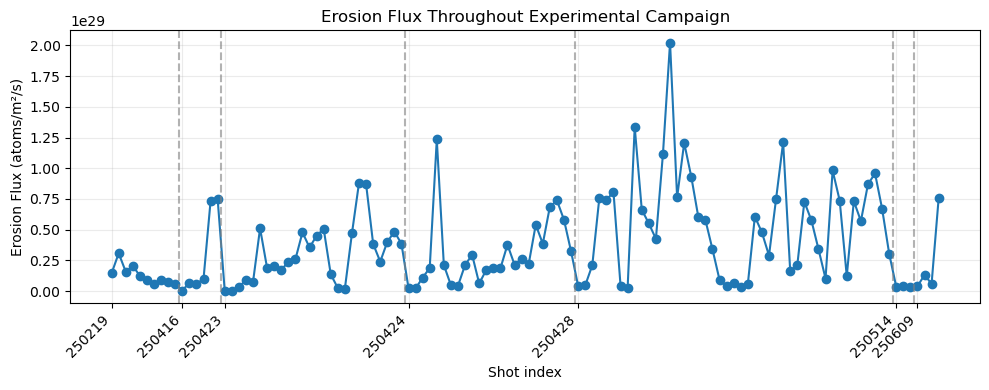

In [73]:
plt.figure(figsize=(10, 4))
plt.plot(x, kept_inner_shell_emiss, marker='o')

# Vertical separators when date prefix changes
change_idxs = [i for i in range(1, len(kept_prefixes)) if kept_prefixes[i] != kept_prefixes[i-1]]
for i in change_idxs:
    plt.axvline(i - 0.5, color='gray', linestyle='--', alpha=0.6)

# Label x-axis by date groups (tick at group starts)
group_starts = [0] + change_idxs
group_labels = [kept_prefixes[i] for i in group_starts]
plt.xticks(group_starts, group_labels, rotation=45, ha='right')

plt.xlabel("Shot index")
plt.ylabel("Erosion Flux (atoms/m²/s)")
plt.title("Erosion Flux Throughout Experimental Campaign")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()